# PROBLEM 1
## Euler vs Euler-Cromer Algorithm for Oscillatory Problems

We consider the simple harmonic oscillator:

$$
\ddot{x} = -x
$$

with initial conditions $x(0) = 1$, $\dot{x}(0) = 0$. The exact solution is $x(t) = \cos(t)$, with constant energy:

$$
E = \frac{1}{2}(v^2 + x^2) = \frac{1}{2}
$$

### Standard Euler Algorithm

The system is discretised as:

$$
v_{n+1} = v_n - \Delta t\, x_n
$$
$$
x_{n+1} = x_n + \Delta t\, v_n
$$

The **past** velocity $v_n$ is used to update the position. Because Euler's method is explicit and first-order, it introduces a systematic phase error and, more critically, **does not conserve energy** — the energy drifts upward over time, causing the amplitude to grow without bound.

### Euler-Cromer Algorithm

A simple improvement: replace $v_n$ with the **updated** velocity $v_{n+1}$ in the position equation:

$$
v_{n+1} = v_n - \Delta t\, x_n
$$
$$
x_{n+1} = x_n + \Delta t\, v_{n+1}
$$


We compare the two methods for three step sizes: $\Delta t = 0.5,\ 0.1,\ 0.01$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Simulation parameters
t_max    = 20           # total simulation time
dt_values = [0.5, 0.1, 0.01]  # three step sizes to compare

# Initial conditions  (exact solution: x(t) = cos(t), E = 0.5)
x0 = 1.0
v0 = 0.0


## Part (a): Standard Euler Method — $t$ vs $x(t)$

For each step size, we run the Euler update:

$$v_{n+1} = v_n - \Delta t\,x_n, \qquad x_{n+1} = x_n + \Delta t\,v_n$$

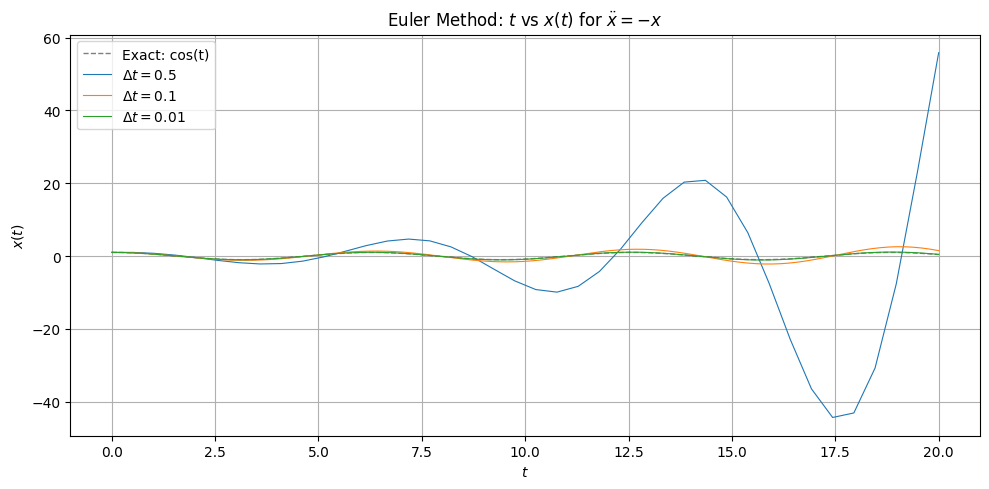

In [7]:
plt.figure(figsize=(10, 5))

# Plot exact solution for reference
t_exact = np.linspace(0, t_max, 2000)
plt.plot(t_exact, np.cos(t_exact), 'k--', linewidth=1.0, alpha=0.5, label='Exact: cos(t)')

# Simulate and plot for each step size
for dt in dt_values:
    N = int(t_max / dt)
    t = np.linspace(0, t_max, N)

    x = np.zeros(N)
    v = np.zeros(N)
    x[0], v[0] = x0, v0

    # The Euler Method Loop
    for n in range(N - 1):
        v[n+1] = v[n] - dt * x[n]
        x[n+1] = x[n] + dt * v[n]   

    plt.plot(t, x, linewidth=0.8, label=rf'$\Delta t = {dt}$')

plt.title(r'Euler Method: $t$ vs $x(t)$ for $\ddot{x} = -x$')
plt.xlabel('$t$')
plt.ylabel('$x(t)$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Observations — Euler Method

- **$\Delta t = 0.5$**: Severe amplitude growth; the oscillation diverges rapidly. The energy is clearly not conserved.
- **$\Delta t = 0.1$**: Slower growth, but the amplitude still drifts upward noticeably over 20 time units.
- **$\Delta t = 0.01$**: Much closer to the exact solution over this interval, but energy will eventually drift for longer simulations.

The Euler method **always gains energy** regardless of step size — making it fundamentally unsuitable for long-term oscillatory simulation.


## Part (b): Euler-Cromer Method — $t$ vs $x(t)$

The only change is using $v_{n+1}$ (the **updated** velocity) to advance position:

$$v_{n+1} = v_n - \Delta t\,x_n, \qquad x_{n+1} = x_n + \Delta t\,v_{n+1}$$


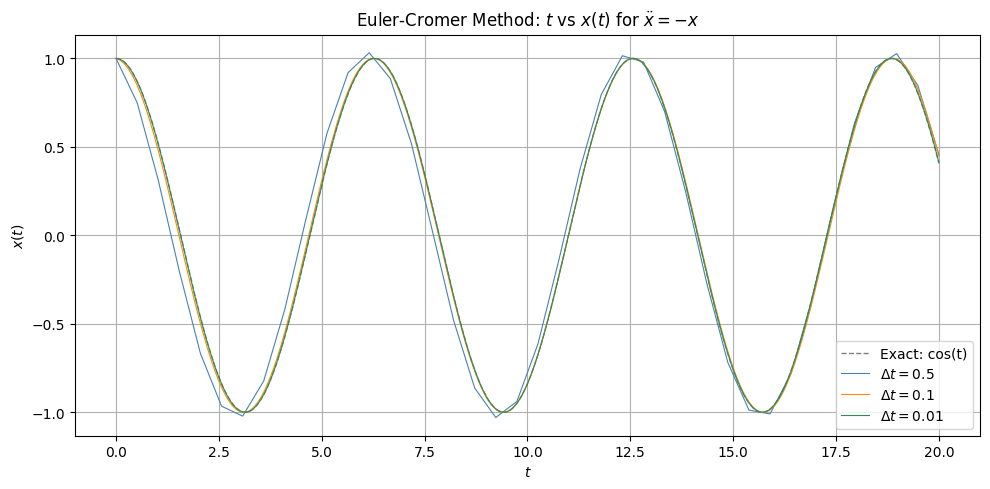

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(t_exact, np.cos(t_exact), 'k--', linewidth=1.0,
         alpha=0.5, label='Exact: cos(t)')

for dt, col in zip(dt_values):
    N = int(t_max / dt)
    t = np.linspace(0, t_max, N)

    x = np.zeros(N)
    v = np.zeros(N)
    x[0], v[0] = x0, v0

    for n in range(N - 1):
        v[n+1] = v[n] - dt * x[n]
        x[n+1] = x[n] + dt * v[n+1]  # uses NEW velocity

    plt.plot(t, x, linewidth=0.8, label=fr'$\Delta t = {dt}$')

plt.title(r'Euler-Cromer Method: $t$ vs $x(t)$ for $\ddot{x} = -x$')
plt.xlabel('$t$')
plt.ylabel('$x(t)$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


### Observations — Euler-Cromer Method

- **$\Delta t = 0.5$**: The amplitude is slightly wrong (phase error) but remains **stable** — no runaway growth.
- **$\Delta t = 0.1$**: Very close to $\cos(t)$; amplitude stays bounded for the full 20 time units.
- **$\Delta t = 0.01$**: Essentially indistinguishable from the exact solution on this scale.

Euler-Cromer is visibly superior: even the coarsest step size does not blow up, which is the key signature of a symplectic integrator.


## Part (c): Energy Conservation — $E_n = \frac{1}{2}(v_n^2 + x_n^2)$

For the exact solution $x(t) = \cos(t)$, the energy is constant:

$$
E = \frac{1}{2}(v^2 + x^2) = \frac{1}{2}(\sin^2 t + \cos^2 t) = \frac{1}{2}
$$

We compute $E_n$ at each time step for both methods using $\Delta t = 0.1$ and compare against the exact value.


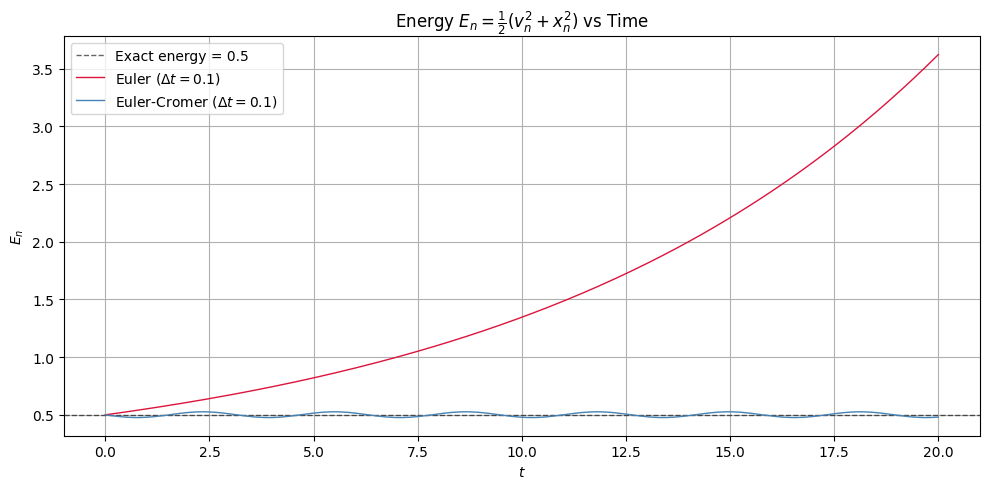

In [8]:
dt = 0.1
N  = int(t_max / dt)
t  = np.linspace(0, t_max, N)

# --- Euler ---
x_e = np.zeros(N);  v_e = np.zeros(N)
x_e[0], v_e[0] = x0, v0
for n in range(N - 1):
    v_e[n+1] = v_e[n] - dt * x_e[n]
    x_e[n+1] = x_e[n] + dt * v_e[n]
E_euler = 0.5 * (v_e**2 + x_e**2)

# --- Euler-Cromer ---
x_c = np.zeros(N);  v_c = np.zeros(N)
x_c[0], v_c[0] = x0, v0
for n in range(N - 1):
    v_c[n+1] = v_c[n] - dt * x_c[n]
    x_c[n+1] = x_c[n] + dt * v_c[n+1]
E_cromer = 0.5 * (v_c**2 + x_c**2)

plt.figure(figsize=(10, 5))
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=1.0,
            alpha=0.6, label='Exact energy = 0.5')
plt.plot(t, E_euler,  color='crimson',   linewidth=1.0, label=r'Euler ($\Delta t=0.1$)')
plt.plot(t, E_cromer, color='steelblue', linewidth=1.0, label=r'Euler-Cromer ($\Delta t=0.1$)')
plt.title(r'Energy $E_n = \frac{1}{2}(v_n^2 + x_n^2)$ vs Time')
plt.xlabel('$t$')
plt.ylabel('$E_n$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


### Observations — Energy

- **Euler**: Energy grows monotonically over time.

- **Euler-Cromer**: Energy oscillates very slightly around the exact value of 0.5 

This contrast explains why the Euler-Cromer method is the preferred choice for conservative and oscillatory systems in computational physics.


## Conclusion

We compared the standard Euler and Euler-Cromer algorithms for  $\ddot{x} = -x$.

- The **Euler method** suffers from systematic energy growth because using the old velocity $v_n$ to update position introduces an asymmetry that continuously injects energy. This makes it unsuitable for long-time oscillatory simulations regardless of step size.

- The **Euler-Cromer method** corrects this with a single change — using the updated velocity $v_{n+1}$ instead. 
